# Predicting Spotify Track Popularity

**Final project topic:** Predicting Spotify track `popularity` using audio features and genre metadata.

**Team:** Tiantian Zheng and Ziling Xu  
**Course:** DSC 148, Spring 2026, UC San Diego

**Research question:** Can Spotify track popularity be predicted from audio characteristics and lightweight metadata, and which features contribute most to popularity?

**Predictive task:** supervised regression, where the target variable is Spotify `popularity` on a 0-100 scale.

**Final report:** `DSC148_Final_Project.pdf`

## Abstract Summary

This project analyzes a Spotify Tracks dataset containing 114,000 songs across 114 genres. We predict each track's numeric popularity score using Spotify audio features, genre labels, explicit-content indicators, duration, and simple engineered metadata. We compare global and genre baselines with Ridge Regression, Random Forest, and HistGradientBoosting regressors. The best model, HistGradientBoosting, achieves an RMSE of about 17.78 and an R2 of about 0.369 on a grouped test split by `track_id`. The results show that popularity is partially predictable from content-based features, but genre and market context provide more predictive signal than individual audio features alone.

## Project Components Checklist

This notebook is organized to match the project instruction components:

| Required component | Where it appears in this notebook |
|---|---|
| Dataset | Section 1: Dataset and EDA |
| Predictive Task | Section 2: Predictive Task |
| Model | Section 3: Model Design and Training |
| Literature | Section 4: Literature Review |
| Results | Section 5: Results and Analysis |

The final paper expands these notebook sections into ACM-style report form.


## 0. Setup and Imports

This section imports the libraries used for data processing, visualization, model training, and evaluation.


In [115]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd()
DATA_PATH = Path(
    "/Users/deidei/.cache/kagglehub/datasets/saichaitanyareddyai/"
    "spotify-tracks-dataset-audio-features/versions/1/"
    "spotify-tracks-dataset-detailed.csv"
)
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

TARGET = "popularity"
RANDOM_STATE = 148


## 1. Dataset and EDA

### 1.1 Load Dataset

The dataset contains 114,000 Spotify tracks across 114 genres. Each row includes track metadata, Spotify audio features, and a numeric popularity score.


In [116]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [117]:
df.info()
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
dtype: int64

### 1.2 Feature Design and Leakage Control

We exclude raw identifiers and high-cardinality text fields from the model input:

- `track_id`
- `artists`
- `album_name`
- `track_name`

These fields could let the model memorize specific songs or artists instead of learning generalizable patterns. The project focuses on audio features and lightweight metadata rather than full text analysis.

We keep Spotify audio features such as `danceability`, `energy`, `acousticness`, `valence`, and `tempo`, plus lightweight metadata such as `track_genre`, `duration_ms`, and `explicit`.


In [118]:
ID_AND_TEXT_COLUMNS = ["track_id", "artists", "album_name", "track_name"]

AUDIO_FEATURES = [
    "danceability", "energy", "key", "loudness", "mode", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
    "time_signature",
]

METADATA_FEATURES = ["duration_ms", "explicit", "track_genre"]

# Simple engineered features. These are not full text analysis; they are lightweight metadata summaries.
df["track_name_length"] = df["track_name"].fillna("").str.len()
df["artist_count"] = df["artists"].fillna("").str.count(";") + 1
df["duration_minutes"] = df["duration_ms"] / 60_000

ENGINEERED_FEATURES = ["track_name_length", "artist_count", "duration_minutes"]
FEATURE_COLUMNS = AUDIO_FEATURES + METADATA_FEATURES + ENGINEERED_FEATURES

summary = {
    "rows": len(df),
    "unique_genres": df["track_genre"].nunique(),
    "unique_artists": df["artists"].nunique(dropna=True),
    "target_summary": df[TARGET].describe().round(3).to_dict(),
    "excluded_columns": ID_AND_TEXT_COLUMNS,
}
summary


{'rows': 114000,
 'unique_genres': 114,
 'unique_artists': 31437,
 'target_summary': {'count': 114000.0,
  'mean': 33.239,
  'std': 22.305,
  'min': 0.0,
  '25%': 17.0,
  '50%': 35.0,
  '75%': 50.0,
  'max': 100.0},
 'excluded_columns': ['track_id', 'artists', 'album_name', 'track_name']}

### 1.3 Exploratory Data Analysis

The EDA is organized to motivate the predictive modeling choices. We first check data quality and granularity, then study the target variable, genre-level context, audio feature distributions, and feature relationships.

The main goal is to connect observed dataset properties to later model choices and ablation studies.


### 1.3.1 Data Quality and Granularity

We first verify missing values and duplicate `track_id` values. This matters because duplicate songs can leak information across train/test splits or overrepresent specific tracks.


In [119]:
basic_quality = pd.DataFrame({
    "value": [
        len(df),
        df.shape[1],
        df["track_id"].nunique(),
        df["track_genre"].nunique(),
        df["artists"].nunique(dropna=True),
        df.duplicated(subset=["track_id"]).sum(),
    ]
}, index=[
    "rows",
    "columns_after_engineering",
    "unique_track_ids",
    "unique_genres",
    "unique_artists",
    "duplicated_track_id_rows",
])

basic_quality


,value
rows,114000
columns_after_engineering,23
unique_track_ids,89741
unique_genres,114
unique_artists,31437
duplicated_track_id_rows,24259


In [120]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].to_frame("missing_count")


,missing_count
album_name,1
track_name,1
artists,1


In [121]:
duplicate_track_rows = df.duplicated(subset=["track_id"]).sum()

if duplicate_track_rows > 0:
    dup_summary = (
        df.groupby("track_id")
        .agg(
            row_count=("track_id", "size"),
            genre_count=("track_genre", "nunique"),
            popularity_values=("popularity", "nunique"),
        )
        .sort_values("row_count", ascending=False)
        .head(10)
    )
    display(dup_summary)
else:
    print("No duplicated track_id values found.")


,row_count,genre_count,popularity_values
track_id,,,
6S3JlDAGk3uu3NtZbPnuhS,9,9,1
2kkvB3RNRzwjFdGhaUA0tz,8,8,1
2Ey6v4Sekh3Z0RUSISRosD,8,8,1
4GPQDyw9hC1DiZVh0ouDVL,7,7,1
61202Zzk9rk4bPMZLh2gr6,7,7,1
3dJjsWCy6ZwMfw5NbD226G,7,6,1
5ftfVzSLIi5ZxYdNbRtf41,7,7,1
4XYieGKSlJlHpzB3bl6WMP,7,7,1
0e5LcankE0UyJUuCoq1uH2,7,7,1


The dataset is large enough for the requirement and has very few missing values. The duplicate-track check tells us whether the row level is truly track-level or whether some songs appear multiple times. Raw IDs and names are still excluded from modeling to reduce memorization.


### 1.3.2 Target Variable: Popularity Distribution

Before modeling, we inspect the target distribution. A broad distribution means the regression task is meaningful; skew or many low-popularity tracks can make prediction harder.


In [122]:
target_summary = df[TARGET].describe().to_frame("popularity")
target_summary


,popularity
count,114000.000000
mean,33.238535
std,22.305078
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


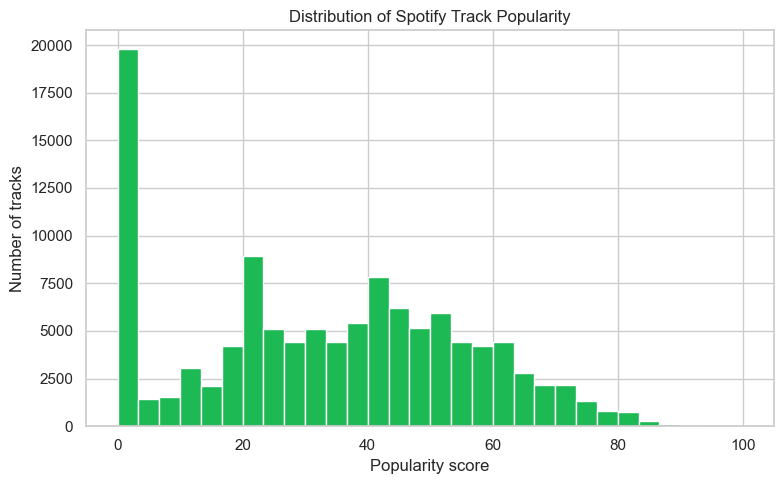

In [123]:
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET], bins=30, color="#1DB954", edgecolor="white")
plt.title("Distribution of Spotify Track Popularity")
plt.xlabel("Popularity score")
plt.ylabel("Number of tracks")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_popularity_distribution.png", dpi=180)
plt.show()


Popularity ranges from 0 to 100, with many songs in the low-to-middle range. This suggests the task is not simply identifying hit songs; the model must predict a wide range of popularity values.


### 1.3.3 Genre and Market Context

Popularity is not only an acoustic property. Genre can encode audience size, playlist ecosystems, and market context, so we inspect genre-level popularity before using `track_genre` as a model feature.


In [124]:
genre_summary = (
    df.groupby("track_genre")[TARGET]
    .agg(["count", "mean", "median", "std"])
    .query("count >= 300")
    .sort_values("mean", ascending=False)
    .round(3)
)

print("Most popular genres:")
display(genre_summary.head(12))

print("Least popular genres:")
display(genre_summary.tail(12).sort_values("mean"))


Most popular genres:


,count,mean,median,std
track_genre,,,,
pop-film,1000,59.283,60.0,10.249
k-pop,1000,56.896,60.0,16.946
chill,1000,53.651,57.0,14.951
sad,1000,52.379,54.0,11.493
grunge,1000,49.594,55.0,18.489
indian,1000,49.539,49.0,11.347
anime,1000,48.772,50.0,11.811
emo,1000,48.128,51.0,17.587
sertanejo,1000,47.866,47.0,3.944


Least popular genres:


,count,mean,median,std
track_genre,,,,
iranian,1000,2.210,0.0,4.174
romance,1000,3.245,0.0,6.296
latin,1000,8.297,0.0,21.962
detroit-techno,1000,11.174,8.0,8.949
chicago-house,1000,12.339,10.0,9.582
classical,1000,13.055,3.0,18.093
jazz,1000,13.628,0.0,23.183
grindcore,1000,14.625,14.0,4.500
kids,1000,14.888,12.0,9.240


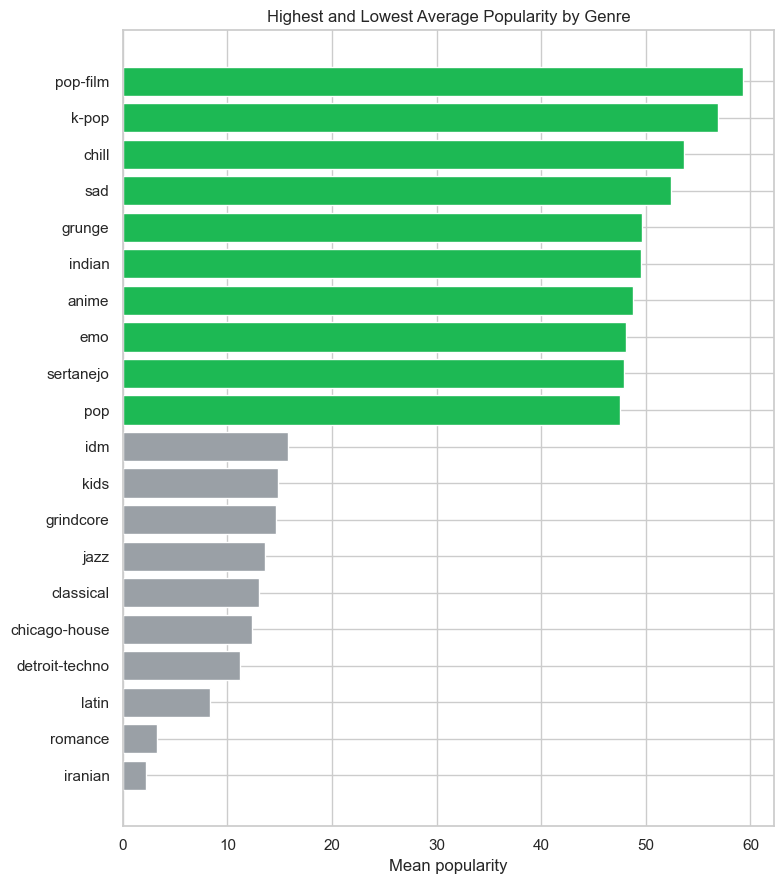

In [125]:
genre_plot = pd.concat([
    genre_summary.head(10),
    genre_summary.tail(10),
]).sort_values("mean")

plt.figure(figsize=(8, 9))
colors = ["#1DB954" if value >= genre_summary["mean"].median() else "#9aa0a6" for value in genre_plot["mean"]]
plt.barh(genre_plot.index, genre_plot["mean"], color=colors)
plt.title("Highest and Lowest Average Popularity by Genre")
plt.xlabel("Mean popularity")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_genre_top_bottom_popularity.png", dpi=180)
plt.show()


Genres differ substantially in average popularity. This motivates an ablation study: compare audio-only prediction against audio-plus-metadata prediction to see how much genre/context improves performance.


### 1.3.4 Audio Feature Distributions

Next, we inspect the main audio variables. These plots help identify skewed features and show whether values cover a useful range for modeling.


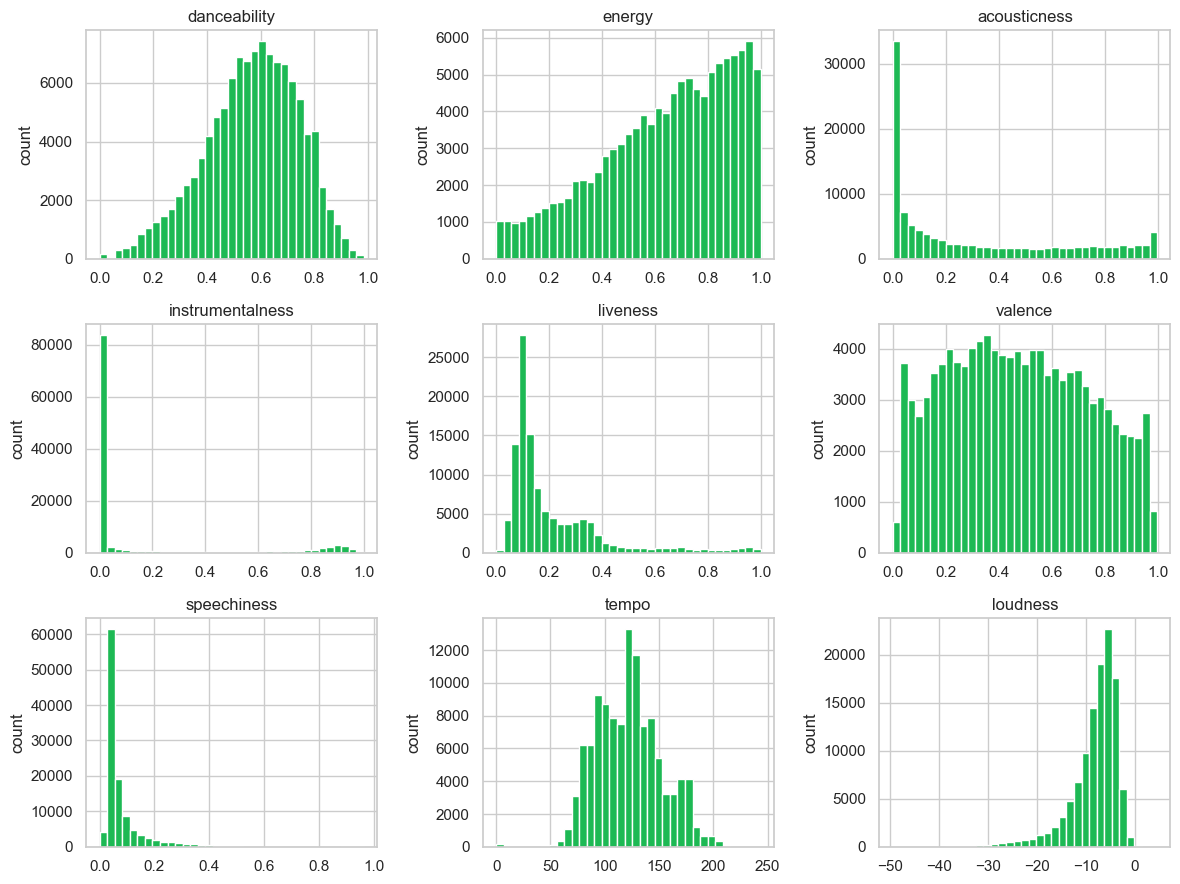

In [126]:
plot_features = [
    "danceability", "energy", "acousticness", "instrumentalness",
    "liveness", "valence", "speechiness", "tempo", "loudness",
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.ravel()

for ax, feature in zip(axes, plot_features):
    ax.hist(df[feature].dropna(), bins=35, color="#1DB954", edgecolor="white")
    ax.set_title(feature)
    ax.set_ylabel("count")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_audio_feature_distributions.png", dpi=180)
plt.show()


Audio features have different shapes: some are fairly spread out, while variables such as instrumentalness and speechiness are often skewed. This supports using tree-based models that do not require strictly normal feature distributions.


### 1.3.5 Audio Feature Relationships with Popularity

We examine both direct correlations with popularity and correlations among features. This helps explain what linear models can capture and where nonlinear models may help.


In [127]:
correlations = (
    df[AUDIO_FEATURES + ["duration_ms", TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
correlations.to_frame("correlation_with_popularity")


,correlation_with_popularity
instrumentalness,-0.095139
loudness,0.050423
speechiness,-0.044927
valence,-0.040534
danceability,0.035448
time_signature,0.031073
acousticness,-0.025472
mode,-0.013931
tempo,0.013205
duration_ms,-0.007101


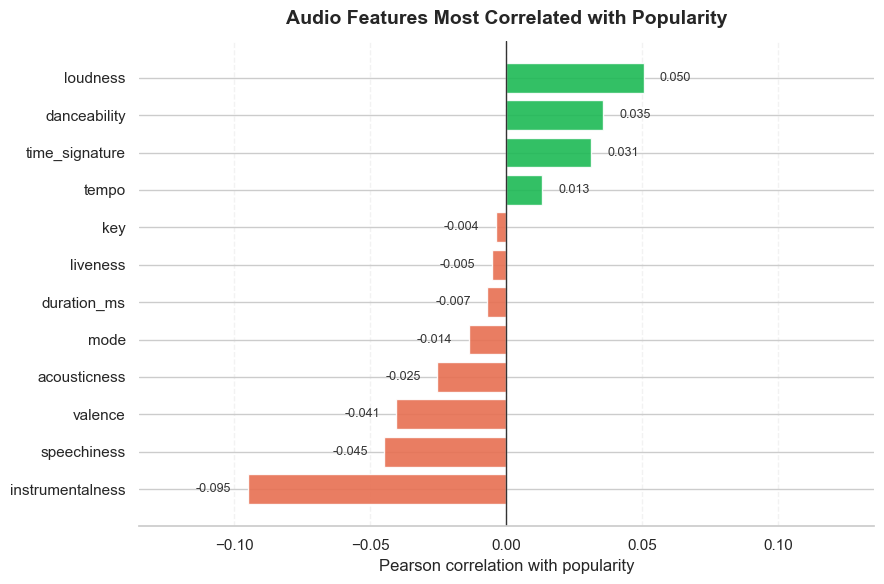

In [128]:
top_corr = correlations.head(12).sort_values()
colors = np.where(top_corr.values >= 0, "#1DB954", "#E76F51")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_corr.index, top_corr.values, color=colors, alpha=0.9)

ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Audio Features Most Correlated with Popularity", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Pearson correlation with popularity")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for bar, value in zip(bars, top_corr.values):
    x_offset = 0.006 if value >= 0 else -0.006
    ha = "left" if value >= 0 else "right"
    ax.text(value + x_offset, bar.get_y() + bar.get_height() / 2, f"{value:.3f}",
            va="center", ha=ha, fontsize=9, color="#333333")

limit = max(abs(top_corr.min()), abs(top_corr.max())) + 0.04
ax.set_xlim(-limit, limit)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_top_correlations.png", dpi=180)
plt.show()


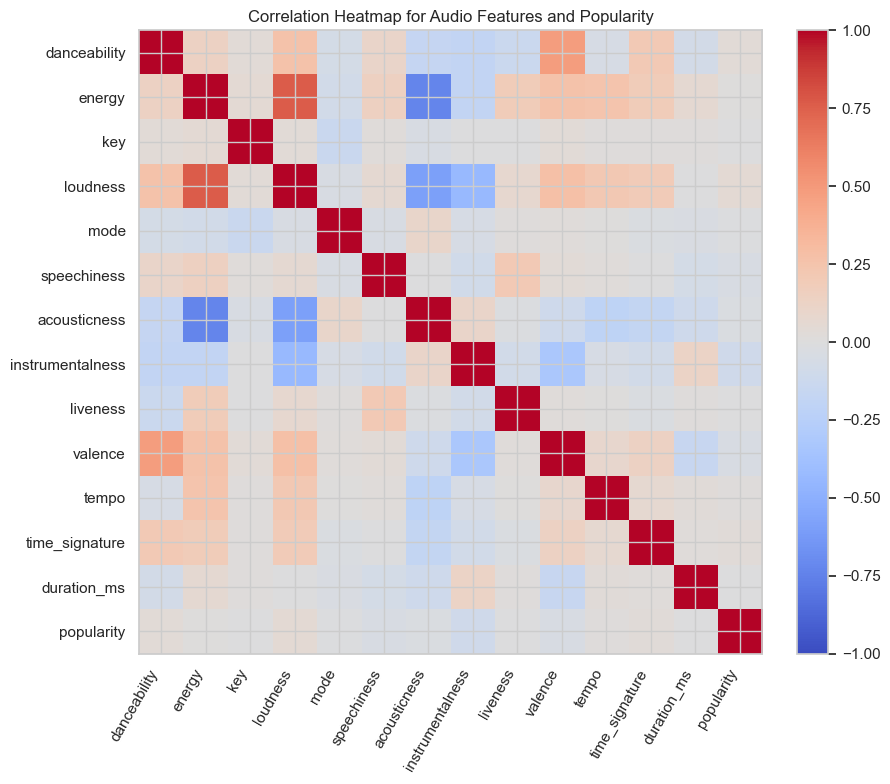

In [129]:
heatmap_features = AUDIO_FEATURES + ["duration_ms", TARGET]
corr_matrix = df[heatmap_features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=60, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap for Audio Features and Popularity")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_audio_correlation_heatmap.png", dpi=180)
plt.show()


Individual audio features have limited correlation with popularity, so a simple one-feature explanation is unlikely. The model needs to combine multiple weak signals, which motivates comparing linear and nonlinear regressors.


### 1.3.6 EDA Summary for Modeling

The EDA motivates three modeling decisions:

1. Use regression because `popularity` is a continuous 0-100 score with a broad distribution.
2. Compare audio-only features against audio-plus-metadata features because genre-level patterns are strong.
3. Use both linear and nonlinear models because individual audio correlations are limited, while feature distributions are skewed and may interact.


## 2. Predictive Task

**Task definition:** Given a Spotify track's audio features and lightweight metadata, predict its numeric `popularity` score.

This is a **regression task** because the target variable is a continuous 0-100 score.

**Evaluation metrics:**

- **MAE:** average absolute prediction error.
- **RMSE:** penalizes large errors more heavily.
- **R2:** measures the proportion of target variance explained by the model.

**Evaluation design:** The train/test split is grouped by `track_id`, so the same track cannot appear in both train and test. This is important because the dataset contains repeated tracks across genres.


In [130]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred, clip=True):
    """Return regression metrics. Clip predictions because popularity is bounded 0-100."""
    if clip:
        y_pred = np.clip(y_pred, 0, 100)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }


class GenreMeanRegressor(BaseEstimator, RegressorMixin):
    """Baseline that predicts the training-set mean popularity for each genre."""

    def __init__(self, genre_col="track_genre"):
        self.genre_col = genre_col

    def fit(self, X, y):
        train = pd.DataFrame({self.genre_col: X[self.genre_col], "target": y})
        self.global_mean_ = float(train["target"].mean())
        self.genre_means_ = train.groupby(self.genre_col)["target"].mean()
        return self

    def predict(self, X):
        return (
            X[self.genre_col]
            .map(self.genre_means_)
            .fillna(self.global_mean_)
            .to_numpy()
        )


def split_feature_types(data, columns):
    numeric = [col for col in columns if pd.api.types.is_numeric_dtype(data[col])]
    categorical = [col for col in columns if col not in numeric]
    return numeric, categorical


def make_preprocessor(numeric_features, categorical_features, scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])


def make_model_pipeline(model, numeric_features, categorical_features, scale_numeric=False):
    return Pipeline([
        ("preprocess", make_preprocessor(numeric_features, categorical_features, scale_numeric)),
        ("model", model),
    ])


In [131]:
X = df[FEATURE_COLUMNS]
y = df[TARGET]
groups = df["track_id"]

# Group split prevents the same track_id from appearing in both train and test.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
train_track_ids = set(groups.iloc[train_idx])
test_track_ids = set(groups.iloc[test_idx])

overlap = train_track_ids.intersection(test_track_ids)
print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Overlapping track_id values between train/test: {len(overlap):,}")

numeric_features, categorical_features = split_feature_types(X_train, FEATURE_COLUMNS)
numeric_features, categorical_features


Train rows: 91,150
Test rows: 22,850
Overlapping track_id values between train/test: 0


(['danceability',
  'energy',
  'key',
  'loudness',
  'mode',
  'speechiness',
  'acousticness',
  'instrumentalness',
  'liveness',
  'valence',
  'tempo',
  'time_signature',
  'duration_ms',
  'explicit',
  'track_name_length',
  'artist_count',
  'duration_minutes'],
 ['track_genre'])

## 3. Model Design and Training

This section compares baselines with linear and nonlinear models.

**Baselines:**

- **Global mean baseline:** predicts the average training-set popularity.
- **Genre mean baseline:** predicts the average training-set popularity for each `track_genre`. This is a strong baseline because EDA shows that genre is closely related to popularity.

**Models:**

- **Ridge Regression:** a regularized linear model.
- **Random Forest:** a nonlinear tree ensemble baseline.
- **HistGradientBoosting:** the main proposed model, chosen because gradient boosting often works well for tabular data and can capture nonlinear interactions between genre, metadata, and audio features.

All model predictions are clipped to the valid popularity range `[0, 100]` before calculating metrics.


In [132]:
models = {
    "Global mean baseline": Pipeline([("model", DummyRegressor(strategy="mean"))]),
    "Genre mean baseline": GenreMeanRegressor(genre_col="track_genre"),
    "Ridge Regression": make_model_pipeline(
        Ridge(alpha=1.0), numeric_features, categorical_features, scale_numeric=True
    ),
    "Random Forest": make_model_pipeline(
        RandomForestRegressor(
            n_estimators=120,
            max_depth=16,
            min_samples_leaf=8,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        numeric_features,
        categorical_features,
    ),
    "HistGradientBoosting": make_model_pipeline(
        HistGradientBoostingRegressor(
            max_iter=260,
            learning_rate=0.08,
            max_leaf_nodes=39,
            l2_regularization=0.03,
            random_state=RANDOM_STATE,
        ),
        numeric_features,
        categorical_features,
    ),
}

rows = []
best_name = None
best_model = None
best_rmse = float("inf")
best_predictions = None

for name, model in models.items():
    model.fit(X_train, y_train)
    raw_pred = model.predict(X_test)
    pred = np.clip(raw_pred, 0, 100)
    metrics = regression_metrics(y_test, pred, clip=False)
    rows.append({"model": name, **metrics})
    if metrics["RMSE"] < best_rmse:
        best_rmse = metrics["RMSE"]
        best_name = name
        best_model = model
        best_predictions = pred

model_results = pd.DataFrame(rows).sort_values("RMSE")
model_results.to_csv(OUTPUT_DIR / "spotify_model_results.csv", index=False)
print(f"Best model: {best_name}")
model_results


Best model: HistGradientBoosting


,model,MAE,RMSE,R2
4,HistGradientBoosting,13.029776,17.782107,0.369169
2,Ridge Regression,14.167060,19.270075,0.259179
1,Genre mean baseline,14.234240,19.355936,0.252563
3,Random Forest,16.495514,20.588636,0.154329
0,Global mean baseline,18.964711,22.389451,-0.000077


## 4. Literature Review

This project connects to prior work in music information retrieval, hit song prediction, and content-based music recommendation.

Prior research has studied whether audio content can predict song popularity or commercial success. Dhanaraj and Logan [3] studied automatic hit song prediction using audio and lyric-based features. Pachet and Roy [4] argued that hit song prediction is difficult because popularity is influenced by many factors beyond musical signal, including exposure, marketing, and social influence. This is closely related to our task because our dataset contains Spotify audio features and genre metadata, but does not include major external popularity drivers such as playlist placement, artist fame, social media attention, or release timing.

Spotify-style audio features are also commonly used in music information retrieval and recommendation. Features such as danceability, energy, valence, acousticness, tempo, and instrumentalness provide structured descriptions of musical content. In content-based recommendation, these features can compare songs without relying on user listening histories. Large-scale music datasets such as the Free Music Archive have also supported research in music classification, recommendation, and analysis [5].

Compared with prior work, this project does not propose a new state-of-the-art algorithm. Instead, its contribution is an empirical analysis of how well Spotify popularity can be predicted from audio features and lightweight metadata. We compare simple baselines, a linear model, and nonlinear tree-based models, then use ablation and error analysis to separate the value of audio features from genre and metadata.

**Connection to our results:** Our conclusions are consistent with prior work: audio features contain some predictive signal, but popularity is only partially explained by musical content. The strong role of `track_genre` and the model's difficulty with high-popularity tracks suggest that market context and external exposure are important missing factors.


## 5. Results and Analysis

### 5.1 Error Analysis

Model comparison tells us which model performs best overall. Error analysis checks where the best model succeeds or fails. We look at errors by true popularity bucket and by genre.

This addresses the project instruction question: **Why does the model fail, and what are interesting failure cases?**


In [133]:
error_df = X_test.copy()
error_df["actual_popularity"] = y_test
error_df["predicted_popularity"] = best_predictions
error_df["absolute_error"] = np.abs(error_df["actual_popularity"] - error_df["predicted_popularity"])
error_df["residual"] = error_df["actual_popularity"] - error_df["predicted_popularity"]
error_df["popularity_bucket"] = pd.cut(
    error_df["actual_popularity"],
    bins=[-1, 33, 66, 100],
    labels=["Low", "Medium", "High"],
)

bucket_errors = (
    error_df.groupby("popularity_bucket", observed=True)
    .agg(
        count=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
        actual_mean=("actual_popularity", "mean"),
        predicted_mean=("predicted_popularity", "mean"),
    )
    .round(3)
)
bucket_errors


,count,MAE,mean_residual,actual_mean,predicted_mean
popularity_bucket,,,,,
Low,11329,12.896,-11.937,13.955,25.892
Medium,10015,10.028,8.424,48.599,40.175
High,1506,34.002,33.993,73.776,39.783


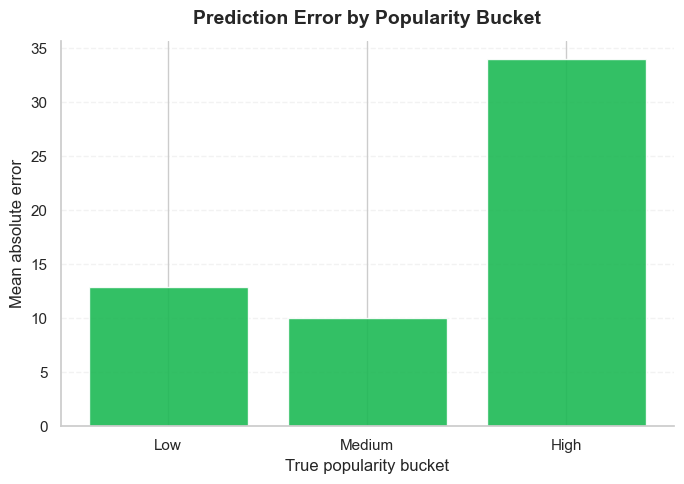

In [134]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(bucket_errors.index.astype(str), bucket_errors["MAE"], color="#1DB954", alpha=0.9)
ax.set_title("Prediction Error by Popularity Bucket", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("True popularity bucket")
ax.set_ylabel("Mean absolute error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_error_by_popularity_bucket.png", dpi=180)
plt.show()


In [135]:
genre_errors = (
    error_df.groupby("track_genre")
    .agg(
        count=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .query("count >= 50")
    .sort_values("MAE", ascending=False)
    .round(3)
)

genre_errors.head(12)


,count,MAE,mean_residual
track_genre,,,
electro,211,29.679,0.783
alternative,191,28.815,1.292
house,206,27.466,1.003
dance,196,27.146,2.347
alt-rock,194,26.889,1.401
pop,181,26.580,-0.518
reggaeton,213,26.111,-1.420
latino,202,25.916,-3.385
edm,209,25.846,-2.548


This analysis shows whether the model performs evenly across popularity levels and genres. If high-popularity tracks have larger errors or positive residuals, the model is underpredicting hits, which is common because true popularity depends on external factors such as playlists, artist fame, and marketing.


### 5.2 Ablation Study

This tests whether audio features alone are enough, and whether metadata improves prediction.

The ablation directly evaluates the effectiveness of feature groups, which is one of the required result analyses in the project instructions.


In [136]:
feature_groups = {
    "Audio features only": AUDIO_FEATURES,
    "Audio + metadata": AUDIO_FEATURES + METADATA_FEATURES,
    "Audio + metadata + simple engineered features": FEATURE_COLUMNS,
}

ablation_rows = []
for group_name, columns in feature_groups.items():
    num_cols, cat_cols = split_feature_types(X_train, columns)
    model = make_model_pipeline(
        HistGradientBoostingRegressor(
            max_iter=220,
            learning_rate=0.08,
            max_leaf_nodes=39,
            l2_regularization=0.03,
            random_state=RANDOM_STATE,
        ),
        num_cols,
        cat_cols,
    )
    model.fit(X_train[columns], y_train)
    pred = model.predict(X_test[columns])
    ablation_rows.append({"feature_set": group_name, **regression_metrics(y_test, pred)})

ablation_results = pd.DataFrame(ablation_rows).sort_values("RMSE")
ablation_results.to_csv(OUTPUT_DIR / "spotify_ablation_results.csv", index=False)
ablation_results


,feature_set,MAE,RMSE,R2
2,Audio + metadata + simple engineered features,13.134147,17.867368,0.363105
1,Audio + metadata,13.265524,18.072332,0.348409
0,Audio features only,16.633016,20.575696,0.155392


### 5.3 Feature Importance

Permutation importance estimates how much each feature matters by measuring how much test error increases when that feature is shuffled.

This helps interpret the model and connect results back to the original research question.


In [137]:
rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(6000, len(X_test))
sample_idx = rng.choice(X_test.index.to_numpy(), size=sample_size, replace=False)
X_sample = X_test.loc[sample_idx, FEATURE_COLUMNS].copy()
y_sample = y_test.loc[sample_idx]

base_rmse = rmse(y_sample, best_model.predict(X_sample))
importance_rows = []

for col in FEATURE_COLUMNS:
    X_perm = X_sample.copy()
    X_perm[col] = rng.permutation(X_perm[col].to_numpy())
    perm_rmse = rmse(y_sample, best_model.predict(X_perm))
    importance_rows.append({
        "feature": col,
        "base_RMSE": base_rmse,
        "permuted_RMSE": perm_rmse,
        "RMSE_increase": perm_rmse - base_rmse,
    })

importance = pd.DataFrame(importance_rows).sort_values("RMSE_increase", ascending=False)
importance.to_csv(OUTPUT_DIR / "spotify_permutation_importance.csv", index=False)
importance.head(12)


,feature,base_RMSE,permuted_RMSE,RMSE_increase
14,track_genre,17.79982,23.232802,5.432982
15,track_name_length,17.79982,18.288904,0.489084
6,acousticness,17.79982,18.252789,0.452968
0,danceability,17.79982,18.250546,0.450726
9,valence,17.79982,18.126220,0.326400
7,instrumentalness,17.79982,18.088447,0.288627
12,duration_ms,17.79982,18.085935,0.286115
5,speechiness,17.79982,18.075910,0.276090
1,energy,17.79982,18.057921,0.258101
3,loudness,17.79982,18.042878,0.243058


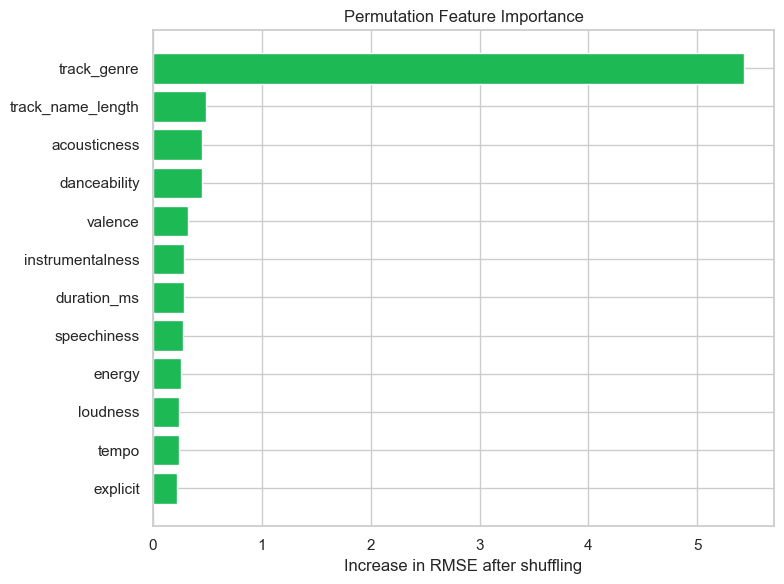

In [138]:
top = importance.head(12).sort_values("RMSE_increase")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["RMSE_increase"], color="#1DB954")
plt.title("Permutation Feature Importance")
plt.xlabel("Increase in RMSE after shuffling")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_permutation_importance.png", dpi=180)
plt.show()


### 5.4 Results Summary

Expected result from the current run:

- The train/test split is grouped by `track_id`, so the same track cannot appear in both sets.
- Best model: HistGradientBoosting.
- HistGradientBoosting achieves RMSE about **17.78** and R2 about **0.369** on the grouped test split.
- The genre mean baseline is much stronger than the global mean baseline, confirming that genre carries important market context.
- HistGradientBoosting still outperforms the genre mean baseline, so audio and metadata features add signal beyond genre averages.
- Audio-only features are useful but limited; adding genre and metadata substantially improves prediction.
- Error analysis shows that high-popularity tracks are often underpredicted, suggesting that missing external factors such as artist fame, playlist placement, marketing, and social trends matter.
- The most important feature is usually `track_genre`, suggesting popularity depends on market and genre context, not only acoustic properties.

Overall, the results support the conclusion that Spotify popularity is only partially predictable from audio content. Metadata, especially genre, adds important context.


## 6. Discussion and Limitations

The results suggest that Spotify track popularity is partially predictable from audio features and lightweight metadata. The best model improves substantially over the global mean baseline and slightly outperforms both Ridge Regression and the genre mean baseline. However, the best R2 is only about 0.369, meaning that a large share of popularity variation remains unexplained.

The strongest limitation is missing external context. Spotify popularity is time-dependent and may depend on playlists, artist popularity, release date, promotional campaigns, social media exposure, and user listening behavior. These variables are not included in the dataset. As a result, the model has particular difficulty with high-popularity tracks, which are likely influenced by factors beyond audio content.

A second limitation is dataset granularity. The dataset contains repeated `track_id` values across multiple genre rows. We address this issue by using a grouped train/test split so that no track ID appears in both training and test sets, but the repeated rows still reflect the dataset's genre-label structure. Future work could aggregate the dataset to one row per unique track or use multi-label genre features.

A third limitation is that we avoid raw artist names and track names to reduce memorization. This makes the task more focused on content-based prediction, but it also removes information that is likely predictive in practice. Artist identity, album reputation, and text information may improve prediction, but they would need to be handled carefully to avoid leakage and overfitting.


## 7. Ethics and Privacy Statement

This project uses a public music dataset containing track-level metadata and audio features rather than private user listening histories. The main ethical risk is not personal privacy, but interpretation: model predictions should not be treated as objective judgments of musical quality.

Popularity reflects platform exposure, audience behavior, and market context. A model trained on historical popularity may reinforce existing visibility patterns if used for recommendation or promotion decisions. Therefore, the model should be interpreted as a predictive analysis tool, not as a measure of artistic value.


## 8. Conclusion

This project examined whether Spotify track popularity can be predicted from audio features and genre metadata. We used a supervised regression framework, grouped train/test splitting by `track_id`, and compared global and genre baselines with Ridge Regression, Random Forest, and HistGradientBoosting. The best model was HistGradientBoosting, achieving an RMSE of 17.78 and R2 of 0.369.

The ablation study showed that audio features alone are useful but limited, while adding genre and lightweight metadata substantially improves performance. Error analysis showed that high-popularity tracks are often underpredicted, indicating that popularity is influenced by external factors not captured in the dataset, such as artist fame, playlist placement, marketing, release timing, and social media trends.

Overall, the main conclusion is that Spotify popularity is only partially predictable from audio content. Genre and metadata provide important context, but popularity is not purely a musical or acoustic property.


## 9. References

[1] Sai Chaitanya Reddy. Spotify Tracks Dataset: Audio Features. Kaggle. Retrieved 2026 from https://www.kaggle.com/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features.

[2] Spotify for Developers. Web API Reference: Audio Features. Retrieved 2026 from https://developer.spotify.com/documentation/web-api/reference/get-audio-features.

[3] R. Dhanaraj and B. Logan. 2005. Automatic Prediction of Hit Songs. In Proceedings of the 6th International Conference on Music Information Retrieval (ISMIR).

[4] F. Pachet and P. Roy. 2008. Hit Song Science Is Not Yet a Science. In Proceedings of the International Conference on Music Information Retrieval (ISMIR).

[5] M. Defferrard, K. Benzi, P. Vandergheynst, and X. Bresson. 2017. FMA: A Dataset for Music Analysis. In Proceedings of the International Society for Music Information Retrieval Conference.

[6] F. Pedregosa et al. 2011. Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research 12, 2825-2830.
